PART A

In [1]:
# Practical 11: Optimization Modeling
# Part A: Optimization Modeling

from scipy.optimize import linprog

# -------------------------------------------------
# Decision Variables
# -------------------------------------------------
# x = Number of units of Product A
# y = Number of units of Product B

# -------------------------------------------------
# Objective Function
# Maximize:
# Profit = 40x + 30y
#
# scipy.optimize.linprog performs minimization,
# so we use negative profit values.
# -------------------------------------------------

profit = [-40, -30]

# -------------------------------------------------
# Constraints
# -------------------------------------------------

# Machine Hours:
# 2x + y <= 100

# Labour Hours:
# x + 2y <= 80

A = [
    [2, 1],
    [1, 2]
]

b = [100, 80]

# -------------------------------------------------
# Non-negative Constraints
# x >= 0
# y >= 0
# -------------------------------------------------

bounds = [
    (0, None),
    (0, None)
]

# -------------------------------------------------
# Solve Linear Programming Problem
# -------------------------------------------------

result = linprog(
    profit,
    A_ub=A,
    b_ub=b,
    bounds=bounds,
    method="highs"
)

# -------------------------------------------------
# Display Result
# -------------------------------------------------

if result.success:

    product_A = result.x[0]
    product_B = result.x[1]

    maximum_profit = -result.fun

    # Calculate resource usage
    machine_used = (2 * product_A) + product_B
    labour_used = product_A + (2 * product_B)

    print("\n===================================")
    print("      OPTIMIZATION MODELING")
    print("===================================")

    print("\nOptimal Production:")
    print("-----------------------------")

    print(f"Product A Units : {product_A:.0f}")
    print(f"Product B Units : {product_B:.0f}")

    print("\nProfit:")
    print("-----------------------------")

    print(f"Maximum Profit  : ₹{maximum_profit:.2f}")

    print("\nResource Usage:")
    print("-----------------------------")

    print(f"Machine Hours Used : {machine_used:.0f} / 100")
    print(f"Labour Hours Used  : {labour_used:.0f} / 80")

    print("\nConstraint Check:")
    print("-----------------------------")

    if machine_used <= 100:
        print("Machine Hours Constraint: Satisfied")
    else:
        print("Machine Hours Constraint: Not Satisfied")

    if labour_used <= 80:
        print("Labour Hours Constraint : Satisfied")
    else:
        print("Labour Hours Constraint : Not Satisfied")

else:

    print("No optimal solution found.")


      OPTIMIZATION MODELING

Optimal Production:
-----------------------------
Product A Units : 40
Product B Units : 20

Profit:
-----------------------------
Maximum Profit  : ₹2200.00

Resource Usage:
-----------------------------
Machine Hours Used : 100 / 100
Labour Hours Used  : 80 / 80

Constraint Check:
-----------------------------
Machine Hours Constraint: Satisfied
Labour Hours Constraint : Satisfied


PART B


       DATASET INFORMATION

First 5 Records:
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001  Electronics  North              195   
1  2022-01-01     S001      P0002     Clothing  North              117   
2  2022-01-01     S001      P0003     Clothing  North              247   
3  2022-01-01     S001      P0004  Electronics  North              139   
4  2022-01-01     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epide

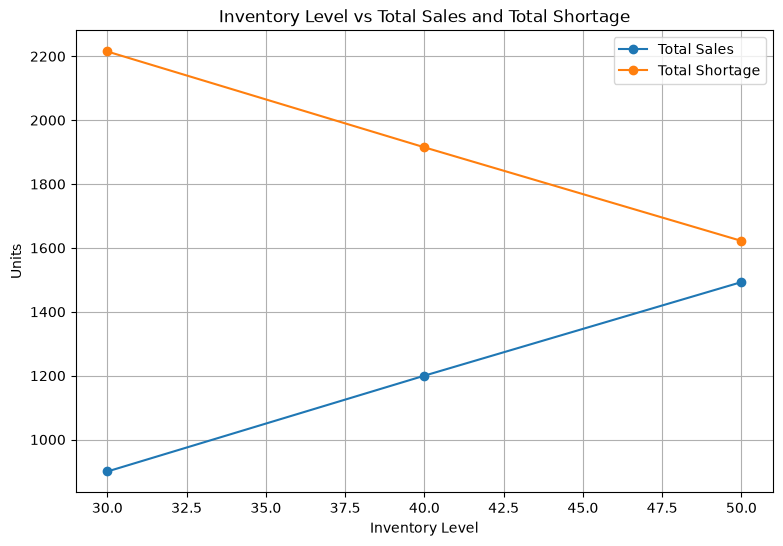

In [4]:
# Practical 11: Simulation Modeling
# Part B: Supermarket Inventory Simulation

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Load Kaggle Dataset
# -------------------------------------------------

file_name = "retail_store_inventory.csv"

df = pd.read_csv(file_name)

print("\n===================================")
print("       DATASET INFORMATION")
print("===================================")

print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Columns:")
print(df.columns.tolist())

# -------------------------------------------------
# 2. Generate 30 Daily Demand Values
# -------------------------------------------------

# Select first 30 demand values from dataset
demand = df["Demand"].head(30).tolist()

days = list(range(1, 31))

print("\n===================================")
print("       DAILY DEMAND - 30 DAYS")
print("===================================")

for day, d in zip(days, demand):
    print(f"Day {day}: {d} units")

# -------------------------------------------------
# 3. Inventory Simulation Function
# -------------------------------------------------

def simulate_inventory(demand, inventory_level):

    units_sold = []
    units_left = []
    shortage = []

    for daily_demand in demand:

        # Units sold cannot be greater than inventory
        sold = min(daily_demand, inventory_level)

        # Units remaining
        remaining = max(inventory_level - daily_demand, 0)

        # Shortage
        short = max(daily_demand - inventory_level, 0)

        units_sold.append(sold)
        units_left.append(remaining)
        shortage.append(short)

    return units_sold, units_left, shortage


# -------------------------------------------------
# 4. Simulation for Inventory = 30
# -------------------------------------------------

sales_30, left_30, shortage_30 = simulate_inventory(
    demand,
    30
)

simulation_30 = pd.DataFrame({
    "Day": days,
    "Demand": demand,
    "Inventory": 30,
    "Units Sold": sales_30,
    "Units Left": left_30,
    "Shortage": shortage_30
})

print("\n===================================")
print("    SIMULATION - INVENTORY = 30")
print("===================================")

print(simulation_30)

print("\nTotal Units Sold:",
      simulation_30["Units Sold"].sum())

print("Total Shortage:",
      simulation_30["Shortage"].sum())


# -------------------------------------------------
# 5. Simulate Inventory Levels
#    30, 40 and 50
# -------------------------------------------------

inventory_levels = [30, 40, 50]

results = []

for inventory in inventory_levels:

    sales, left, shortage = simulate_inventory(
        demand,
        inventory
    )

    total_sales = sum(sales)
    total_shortage = sum(shortage)

    results.append({
        "Inventory Level": inventory,
        "Total Sales": total_sales,
        "Total Shortage": total_shortage
    })


# -------------------------------------------------
# 6. Store Results in DataFrame
# -------------------------------------------------

results_df = pd.DataFrame(results)

print("\n===================================")
print("      INVENTORY COMPARISON")
print("===================================")

print(results_df)


# -------------------------------------------------
# 7. Display Best Sales and Shortage Results
# -------------------------------------------------

print("\n===================================")
print("          ANALYSIS")
print("===================================")

highest_sales = results_df.loc[
    results_df["Total Sales"].idxmax()
]

lowest_shortage = results_df.loc[
    results_df["Total Shortage"].idxmin()
]

print(
    f"Highest Total Sales: "
    f"Inventory {highest_sales['Inventory Level']} units"
)

print(
    f"Lowest Total Shortage: "
    f"Inventory {lowest_shortage['Inventory Level']} units"
)


# -------------------------------------------------
# 8. Create Chart
# -------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Inventory Level"],
    results_df["Total Sales"],
    marker="o",
    label="Total Sales"
)

plt.plot(
    results_df["Inventory Level"],
    results_df["Total Shortage"],
    marker="o",
    label="Total Shortage"
)

plt.xlabel("Inventory Level")
plt.ylabel("Units")

plt.title(
    "Inventory Level vs Total Sales and Total Shortage"
)

plt.legend()

plt.grid(True)

plt.show()


# -------------------------------------------------
# 9. Save Results
# -------------------------------------------------

results_df.to_csv(
    "inventory_simulation_results.csv",
    index=False
)